In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# States (Phonemes)
states = ['S1 (/h/)', 'S2 (/e/)', 'S3 (/l/)', 'S4 (/o/)']
n_states = len(states)

# Observations (Feature Vectors)
observations = ['O1 (/h/)', 'O2 (/e/)', 'O3 (/l/)', 'O4 (/o/)']
observation_sequence = [0, 1, 2, 3]  # Indices for O1, O2, O3, O4
n_observations = len(observations)

# Transition Probability Matrix (A)
# A[i][j] = P(S_j | S_i) - probability of transitioning from state i to state j
transition_prob = np.array([
    [0.4, 0.6, 0.0, 0.0],  # From S1 (/h/)
    [0.0, 0.3, 0.7, 0.0],  # From S2 (/e/)
    [0.0, 0.0, 0.5, 0.5],  # From S3 (/l/)
    [0.0, 0.0, 0.0, 1.0]   # From S4 (/o/)
])

# Emission Probability Matrix (B)
# B[i][j] = P(O_j | S_i) - probability of observing O_j from state S_i
emission_prob = np.array([
    [0.9, 0.1, 0.0, 0.0],  # From S1 (/h/)
    [0.1, 0.8, 0.1, 0.0],  # From S2 (/e/)
    [0.0, 0.1, 0.8, 0.1],  # From S3 (/l/)
    [0.0, 0.0, 0.1, 0.9]   # From S4 (/o/)
])

# Initial Probabilities (π)
initial_prob = np.array([1.0, 0.0, 0.0, 0.0])  # Start with S1 (/h/)

print("HMM Parameters Initialized Successfully!")
print(f"Number of States: {n_states}")
print(f"Number of Observations: {n_observations}")

HMM Parameters Initialized Successfully!
Number of States: 4
Number of Observations: 4


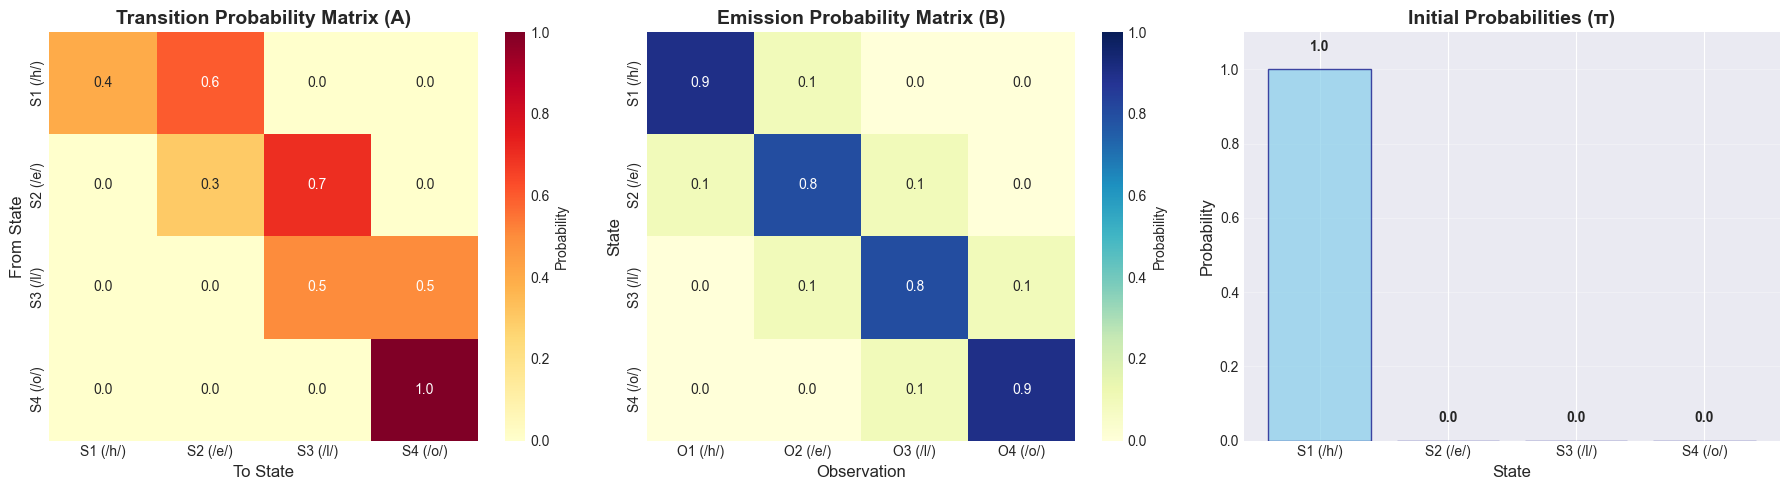

In [3]:
# Visualize Transition Probability Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Transition Matrix Heatmap
sns.heatmap(transition_prob, annot=True, fmt='.1f', cmap='YlOrRd', 
            xticklabels=states, yticklabels=states, ax=axes[0], 
            cbar_kws={'label': 'Probability'}, vmin=0, vmax=1)
axes[0].set_title('Transition Probability Matrix (A)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('To State', fontsize=12)
axes[0].set_ylabel('From State', fontsize=12)

# Emission Matrix Heatmap
sns.heatmap(emission_prob, annot=True, fmt='.1f', cmap='YlGnBu', 
            xticklabels=observations, yticklabels=states, ax=axes[1], 
            cbar_kws={'label': 'Probability'}, vmin=0, vmax=1)
axes[1].set_title('Emission Probability Matrix (B)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Observation', fontsize=12)
axes[1].set_ylabel('State', fontsize=12)

# Initial Probabilities Bar Chart
axes[2].bar(states, initial_prob, color='skyblue', edgecolor='navy', alpha=0.7)
axes[2].set_title('Initial Probabilities (π)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('State', fontsize=12)
axes[2].set_ylabel('Probability', fontsize=12)
axes[2].set_ylim([0, 1.1])
axes[2].grid(axis='y', alpha=0.3)

for i, v in enumerate(initial_prob):
    axes[2].text(i, v + 0.05, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [4]:
def viterbi_algorithm(observations, states, initial_prob, transition_prob, emission_prob):
    
    n_states = len(states)
    n_obs = len(observations)
    
    # Initialize Viterbi matrix and path matrix
    viterbi_matrix = np.zeros((n_states, n_obs))
    path_matrix = np.zeros((n_states, n_obs), dtype=int)
    
    # Step 1: Initialization (t=0)
    print("=" * 70)
    print("VITERBI ALGORITHM - STEP BY STEP EXECUTION")
    print("=" * 70)
    print("\nStep 1: INITIALIZATION (t=0)")
    print("-" * 70)
    
    for s in range(n_states):
        viterbi_matrix[s, 0] = initial_prob[s] * emission_prob[s, observations[0]]
        print(f"δ₁({states[s]}) = π({states[s]}) × B({states[s]}, O1)")
        print(f"         = {initial_prob[s]:.4f} × {emission_prob[s, observations[0]]:.4f}")
        print(f"         = {viterbi_matrix[s, 0]:.6f}\n")
    
    # Step 2: Recursion (t=1 to T-1)
    print("\nStep 2: RECURSION")
    print("-" * 70)
    
    for t in range(1, n_obs):
        print(f"\n--- Time Step t={t+1} (Observation: O{t+1}) ---\n")
        
        for s in range(n_states):
            # Calculate probabilities from all previous states
            probabilities = []
            for prev_s in range(n_states):
                prob = viterbi_matrix[prev_s, t-1] * transition_prob[prev_s, s] * emission_prob[s, observations[t]]
                probabilities.append(prob)
            
            # Find maximum probability and the state that gave it
            max_prob = max(probabilities)
            max_state = probabilities.index(max_prob)
            
            viterbi_matrix[s, t] = max_prob
            path_matrix[s, t] = max_state
            
            print(f"δ{t+1}({states[s]}) = max[δ{t}(Sᵢ) × A(Sᵢ, {states[s]}) × B({states[s]}, O{t+1})]")
            for prev_s in range(n_states):
                marker = " ← MAX" if prev_s == max_state else ""
                print(f"  From {states[prev_s]}: {viterbi_matrix[prev_s, t-1]:.6f} × "
                      f"{transition_prob[prev_s, s]:.1f} × {emission_prob[s, observations[t]]:.1f} = "
                      f"{probabilities[prev_s]:.6f}{marker}")
            print(f"  Selected: {states[max_state]} → {states[s]}")
            print(f"  δ{t+1}({states[s]}) = {max_prob:.6f}\n")
    
    # Step 3: Termination - Find the best final state
    print("\nStep 3: TERMINATION")
    print("-" * 70)
    
    best_last_state = np.argmax(viterbi_matrix[:, -1])
    max_probability = viterbi_matrix[best_last_state, -1]
    
    print(f"Best final state: {states[best_last_state]}")
    print(f"Maximum probability: {max_probability:.6f}\n")
    
    # Step 4: Backtracking to find the best path
    print("\nStep 4: BACKTRACKING")
    print("-" * 70)
    
    best_path = [best_last_state]
    for t in range(n_obs - 1, 0, -1):
        best_path.insert(0, path_matrix[best_path[0], t])
        print(f"t={t}: Previous best state = {states[best_path[0]]}")
    
    print(f"\nFinal Best Path (indices): {best_path}")
    print(f"Final Best Path (states): {[states[i] for i in best_path]}")
    print("=" * 70)
    
    return best_path, max_probability, viterbi_matrix, path_matrix

# Execute Viterbi Algorithm
best_path, max_prob, viterbi_matrix, path_matrix = viterbi_algorithm(
    observation_sequence, states, initial_prob, transition_prob, emission_prob
)

VITERBI ALGORITHM - STEP BY STEP EXECUTION

Step 1: INITIALIZATION (t=0)
----------------------------------------------------------------------
δ₁(S1 (/h/)) = π(S1 (/h/)) × B(S1 (/h/), O1)
         = 1.0000 × 0.9000
         = 0.900000

δ₁(S2 (/e/)) = π(S2 (/e/)) × B(S2 (/e/), O1)
         = 0.0000 × 0.1000
         = 0.000000

δ₁(S3 (/l/)) = π(S3 (/l/)) × B(S3 (/l/), O1)
         = 0.0000 × 0.0000
         = 0.000000

δ₁(S4 (/o/)) = π(S4 (/o/)) × B(S4 (/o/), O1)
         = 0.0000 × 0.0000
         = 0.000000


Step 2: RECURSION
----------------------------------------------------------------------

--- Time Step t=2 (Observation: O2) ---

δ2(S1 (/h/)) = max[δ1(Sᵢ) × A(Sᵢ, S1 (/h/)) × B(S1 (/h/), O2)]
  From S1 (/h/): 0.900000 × 0.4 × 0.1 = 0.036000 ← MAX
  From S2 (/e/): 0.000000 × 0.0 × 0.1 = 0.000000
  From S3 (/l/): 0.000000 × 0.0 × 0.1 = 0.000000
  From S4 (/o/): 0.000000 × 0.0 × 0.1 = 0.000000
  Selected: S1 (/h/) → S1 (/h/)
  δ2(S1 (/h/)) = 0.036000

δ2(S2 (/e/)) = max[δ1(Sᵢ) × 

In [5]:
print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)

print("\n📊 DECODED PHONEME SEQUENCE:")
print("-" * 70)
decoded_sequence = [states[i] for i in best_path]
for i, (obs, state) in enumerate(zip(observations, decoded_sequence), 1):
    print(f"  Observation {i} ({obs}) → {state}")

print(f"\n🎯 Most Likely Phoneme Sequence: {' → '.join(decoded_sequence)}")
print(f"📈 Probability of Best Path: {max_prob:.8f}")
print(f"📉 Log Probability: {np.log(max_prob):.4f}")

# Create a summary DataFrame
results_df = pd.DataFrame({
    'Time Step': range(1, len(observations) + 1),
    'Observation': observations,
    'Decoded State': decoded_sequence,
    'State Index': best_path
})

print("\n" + "="*70)
print("\nSummary Table:")
print(results_df.to_string(index=False))
print("\n" + "="*70)


FINAL RESULTS

📊 DECODED PHONEME SEQUENCE:
----------------------------------------------------------------------
  Observation 1 (O1 (/h/)) → S1 (/h/)
  Observation 2 (O2 (/e/)) → S2 (/e/)
  Observation 3 (O3 (/l/)) → S3 (/l/)
  Observation 4 (O4 (/o/)) → S4 (/o/)

🎯 Most Likely Phoneme Sequence: S1 (/h/) → S2 (/e/) → S3 (/l/) → S4 (/o/)
📈 Probability of Best Path: 0.10886400
📉 Log Probability: -2.2177


Summary Table:
 Time Step Observation Decoded State  State Index
         1    O1 (/h/)      S1 (/h/)            0
         2    O2 (/e/)      S2 (/e/)            1
         3    O3 (/l/)      S3 (/l/)            2
         4    O4 (/o/)      S4 (/o/)            3



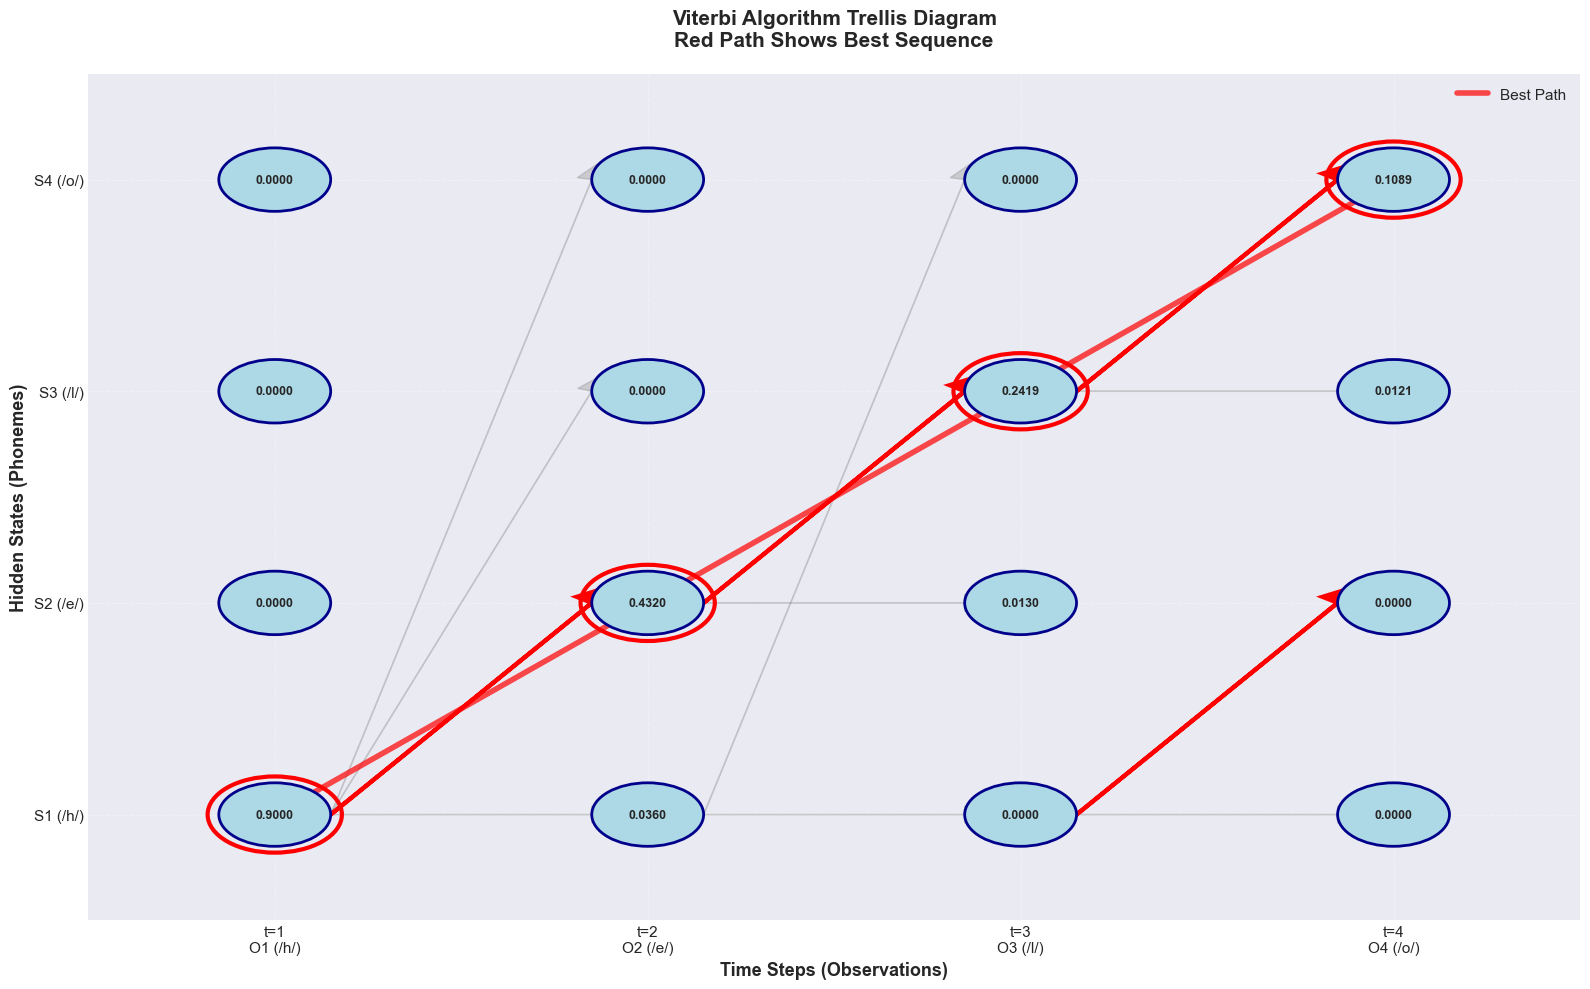

In [6]:
# Visualize the Viterbi Trellis Diagram
fig, ax = plt.subplots(figsize=(16, 10))

n_obs = len(observations)
n_states = len(states)

# Plot grid
for t in range(n_obs):
    for s in range(n_states):
        # Draw node
        circle = plt.Circle((t, s), 0.15, color='lightblue', ec='darkblue', linewidth=2, zorder=3)
        ax.add_patch(circle)
        
        # Add probability value
        prob_text = f'{viterbi_matrix[s, t]:.4f}'
        ax.text(t, s, prob_text, ha='center', va='center', fontsize=9, fontweight='bold', zorder=4)
        
        # Draw transitions
        if t < n_obs - 1:
            next_state = path_matrix[:, t+1]
            for next_s in range(n_states):
                if path_matrix[next_s, t+1] == s:
                    # This is part of the best path
                    if next_s in best_path and s == best_path[best_path.index(next_s) - 1] if next_s in best_path[1:] else False:
                        ax.arrow(t + 0.15, s, 0.7, next_s - s, 
                                head_width=0.1, head_length=0.1, fc='red', ec='red', linewidth=3, zorder=2)
                    else:
                        ax.arrow(t + 0.15, s, 0.7, next_s - s, 
                                head_width=0.08, head_length=0.08, fc='gray', ec='gray', 
                                linewidth=1, alpha=0.3, zorder=1)

# Highlight best path
for i, state_idx in enumerate(best_path):
    circle = plt.Circle((i, state_idx), 0.18, color='red', fill=False, linewidth=3, zorder=5)
    ax.add_patch(circle)

# Draw best path connections
for i in range(len(best_path) - 1):
    ax.plot([i, i+1], [best_path[i], best_path[i+1]], 
            'r-', linewidth=4, alpha=0.7, zorder=2, label='Best Path' if i == 0 else '')

# Labels
ax.set_xticks(range(n_obs))
ax.set_xticklabels([f't={i+1}\n{obs}' for i, obs in enumerate(observations)], fontsize=11)
ax.set_yticks(range(n_states))
ax.set_yticklabels(states, fontsize=11)
ax.set_xlabel('Time Steps (Observations)', fontsize=13, fontweight='bold')
ax.set_ylabel('Hidden States (Phonemes)', fontsize=13, fontweight='bold')
ax.set_title('Viterbi Algorithm Trellis Diagram\nRed Path Shows Best Sequence', 
             fontsize=15, fontweight='bold', pad=20)

ax.set_xlim(-0.5, n_obs - 0.5)
ax.set_ylim(-0.5, n_states - 0.5)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

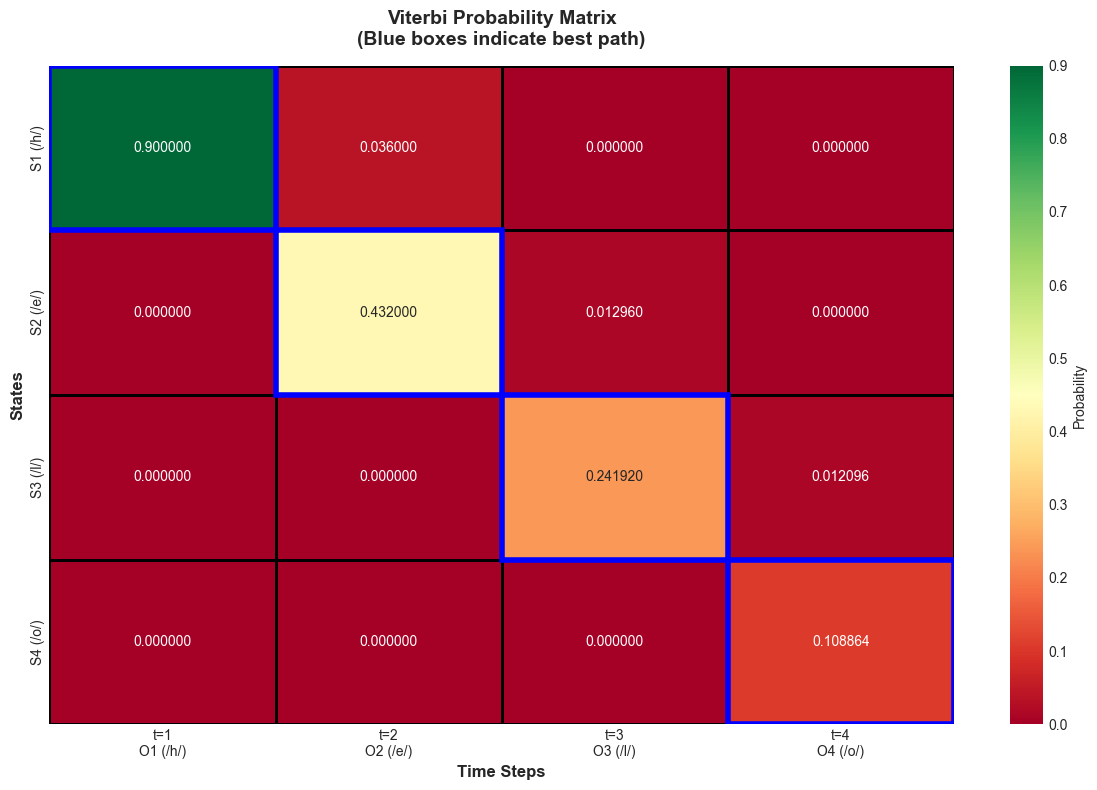

In [7]:
# Create a detailed heatmap of the Viterbi matrix
fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap
sns.heatmap(viterbi_matrix, annot=True, fmt='.6f', cmap='RdYlGn', 
            xticklabels=[f't={i+1}\n{obs}' for i, obs in enumerate(observations)],
            yticklabels=states, ax=ax, cbar_kws={'label': 'Probability'},
            linewidths=2, linecolor='black')

# Highlight best path
for i, state_idx in enumerate(best_path):
    ax.add_patch(plt.Rectangle((i, state_idx), 1, 1, fill=False, 
                               edgecolor='blue', lw=4))

ax.set_title('Viterbi Probability Matrix\n(Blue boxes indicate best path)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Time Steps', fontsize=12, fontweight='bold')
ax.set_ylabel('States', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

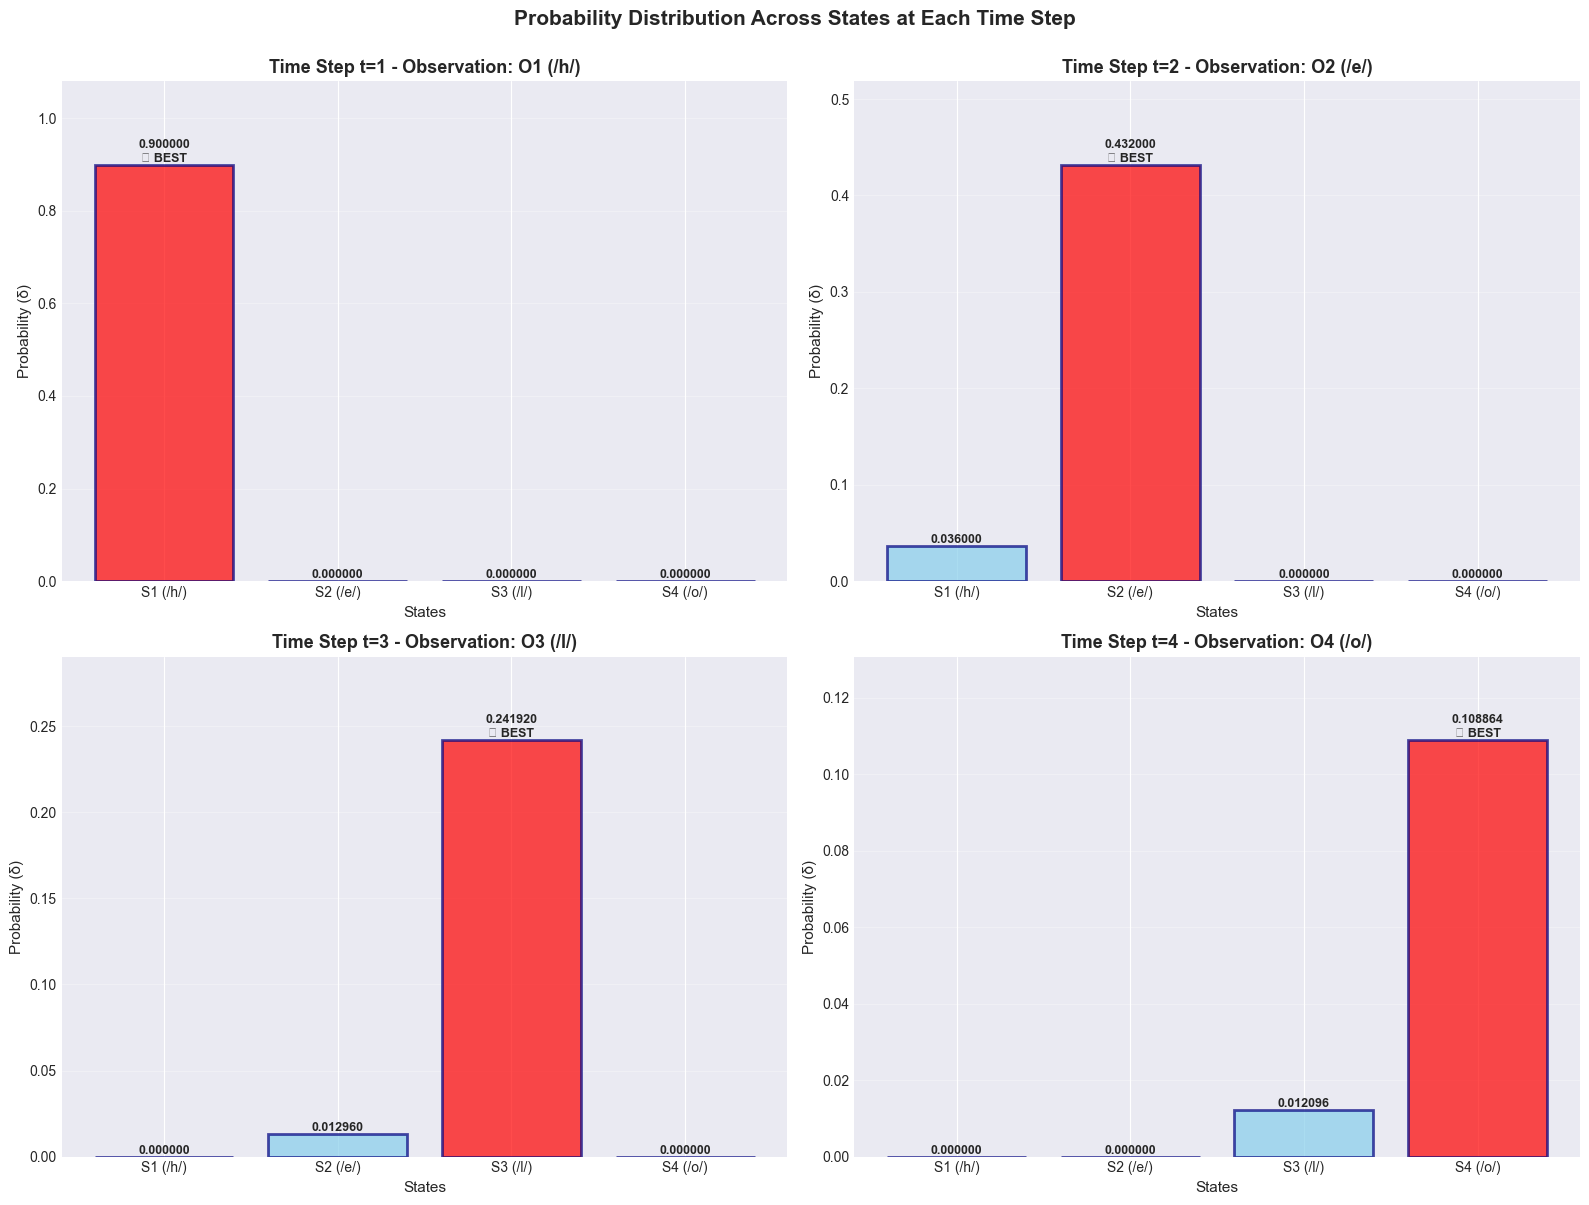

In [8]:
# Compare probabilities at each time step
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for t in range(n_obs):
    ax = axes[t]
    probs = viterbi_matrix[:, t]
    colors = ['red' if i == best_path[t] else 'skyblue' for i in range(n_states)]
    
    bars = ax.bar(states, probs, color=colors, edgecolor='navy', alpha=0.7, linewidth=2)
    ax.set_title(f'Time Step t={t+1} - Observation: {observations[t]}', 
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Probability (δ)', fontsize=11)
    ax.set_xlabel('States', fontsize=11)
    ax.set_ylim([0, max(probs) * 1.2])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, prob) in enumerate(zip(bars, probs)):
        height = bar.get_height()
        label = f'{prob:.6f}'
        if i == best_path[t]:
            label += '\n★ BEST'
        ax.text(bar.get_x() + bar.get_width()/2., height,
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Probability Distribution Across States at Each Time Step', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

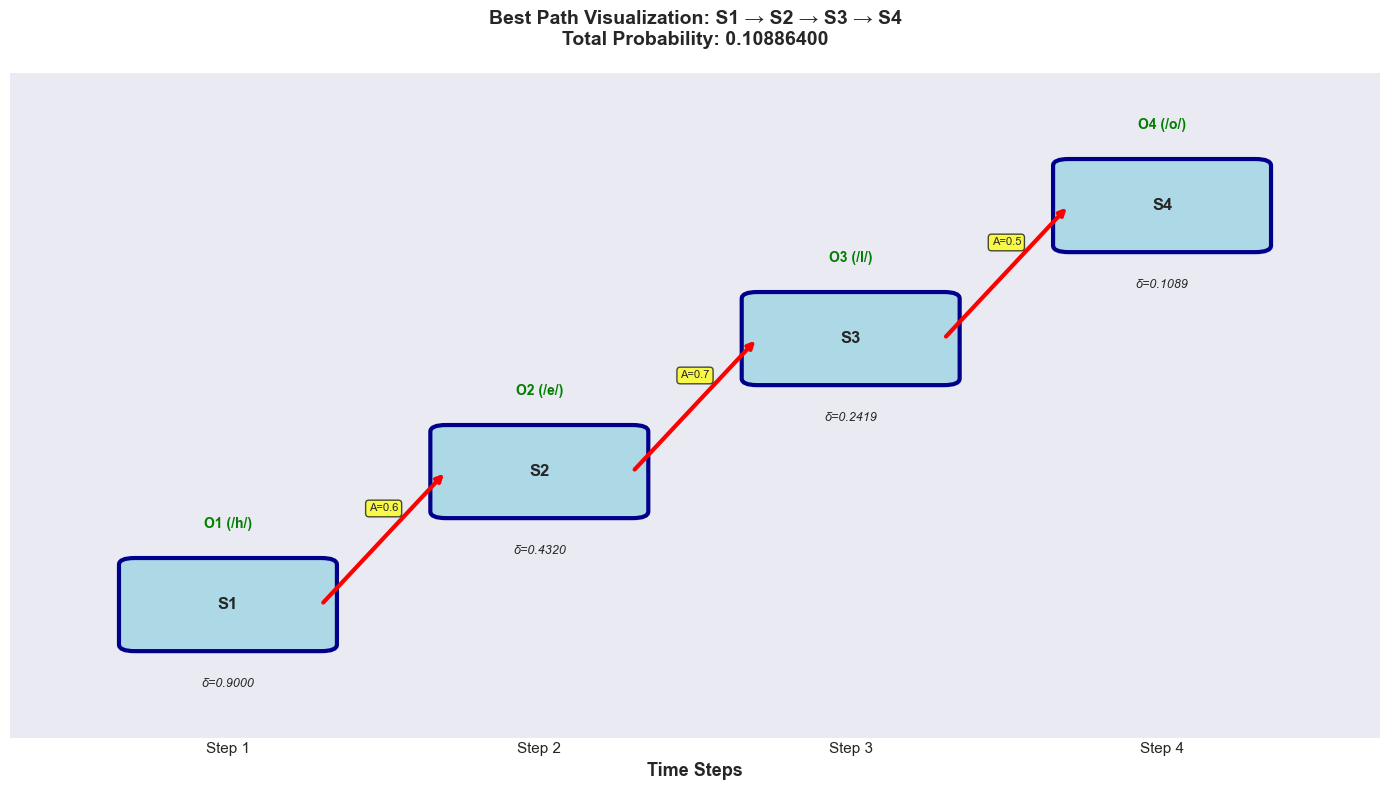

In [10]:
# Create a path flow visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Define positions
x_positions = np.arange(n_obs)
y_positions = {state: i for i, state in enumerate(states)}

# Draw the flow
for i in range(len(best_path)):
    x = x_positions[i]
    y = best_path[i]
    
    # Draw node
    rect = FancyBboxPatch((x - 0.3, y - 0.3), 0.6, 0.6, 
                          boxstyle="round,pad=0.05", 
                          edgecolor='darkblue', facecolor='lightblue', 
                          linewidth=3)
    ax.add_patch(rect)
    
    # Add state label
    ax.text(x, y, states[y].split()[0], ha='center', va='center', 
            fontsize=12, fontweight='bold')
    
    # Add probability below
    ax.text(x, y - 0.55, f'δ={viterbi_matrix[y, i]:.4f}', 
            ha='center', va='top', fontsize=9, style='italic')
    
    # Add observation above
    ax.text(x, y + 0.55, observations[i], 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='green')
    
    # Draw arrow to next state
    if i < len(best_path) - 1:
        next_y = best_path[i + 1]
        ax.annotate('', xy=(x + 0.7, next_y), xytext=(x + 0.3, y),
                   arrowprops=dict(arrowstyle='->', lw=3, color='red'))
        
        # Add transition probability on arrow
        trans_prob = transition_prob[y, next_y]
        mid_x = x + 0.5
        mid_y = (y + next_y) / 2
        ax.text(mid_x, mid_y + 0.2, f'A={trans_prob:.1f}', 
                ha='center', fontsize=8, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax.set_xlim(-0.7, n_obs - 0.3)
ax.set_ylim(-1, n_states)
ax.set_xticks(x_positions)
ax.set_xticklabels([f'Step {i+1}' for i in range(n_obs)], fontsize=11)
ax.set_yticks([])
ax.set_xlabel('Time Steps', fontsize=13, fontweight='bold')
ax.set_title(f'Best Path Visualization: {" → ".join([s.split()[0] for s in decoded_sequence])}\n' + 
             f'Total Probability: {max_prob:.8f}', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()